<a href="https://colab.research.google.com/github/sanodyaJinadasa/InspiHER_Hacktronix/blob/main/ML_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Student Performance Prediction

##### This project focuses on predicting whether a student will pass or fail an exam using Machine Learning techniques. The dataset contains information about students’ study hours, attendance percentage, and exam results.

##### The main objective is to build a best classification model that can accurately predict student performance based on input features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

In [2]:
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
file_path = '/content/drive/MyDrive/Outliers.ipynb/Final_Marks_Data.csv'
df = pd.read_csv(file_path)

In [4]:
print(df.head())

  Student_ID  Attendance (%)  Internal Test 1 (out of 40)  \
0      S1000              84                           30   
1      S1001              91                           24   
2      S1002              73                           29   
3      S1003              80                           36   
4      S1004              84                           31   

   Internal Test 2 (out of 40)  Assignment Score (out of 10)  \
0                           36                             7   
1                           38                             6   
2                           26                             7   
3                           35                             7   
4                           37                             8   

   Daily Study Hours  Final Exam Marks (out of 100)  
0                  3                             72  
1                  3                             56  
2                  3                             56  
3                  3            

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Student_ID                     2000 non-null   object
 1   Attendance (%)                 2000 non-null   int64 
 2   Internal Test 1 (out of 40)    2000 non-null   int64 
 3   Internal Test 2 (out of 40)    2000 non-null   int64 
 4   Assignment Score (out of 10)   2000 non-null   int64 
 5   Daily Study Hours              2000 non-null   int64 
 6   Final Exam Marks (out of 100)  2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB
None


In [6]:
print(df.isnull().sum())

Student_ID                       0
Attendance (%)                   0
Internal Test 1 (out of 40)      0
Internal Test 2 (out of 40)      0
Assignment Score (out of 10)     0
Daily Study Hours                0
Final Exam Marks (out of 100)    0
dtype: int64


In [7]:
df.describe()

,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,84.891500,32.115500,32.464500,7.507000,2.823500,64.855000
std,7.758855,4.563504,4.522827,1.021015,0.608714,11.341265
min,52.000000,18.000000,16.000000,4.000000,1.000000,25.000000
25%,80.000000,29.000000,29.000000,7.000000,2.000000,58.000000
50%,85.000000,32.000000,33.000000,8.000000,3.000000,65.000000
75%,90.000000,35.000000,36.000000,8.000000,3.000000,73.000000
max,100.000000,40.000000,40.000000,10.000000,5.000000,100.000000


In [8]:
df.duplicated().sum()

np.int64(0)

#Pre Processing

In [9]:
df = df.dropna()

In [10]:
df['Result'] = df['Final Exam Marks (out of 100)'].apply(
    lambda x: 'Pass' if x >= 50 else 'Fail'
)

In [11]:
print(df.head())

  Student_ID  Attendance (%)  Internal Test 1 (out of 40)  \
0      S1000              84                           30   
1      S1001              91                           24   
2      S1002              73                           29   
3      S1003              80                           36   
4      S1004              84                           31   

   Internal Test 2 (out of 40)  Assignment Score (out of 10)  \
0                           36                             7   
1                           38                             6   
2                           26                             7   
3                           35                             7   
4                           37                             8   

   Daily Study Hours  Final Exam Marks (out of 100) Result  
0                  3                             72   Pass  
1                  3                             56   Pass  
2                  3                             56   Pass  
3   

Pair Plot

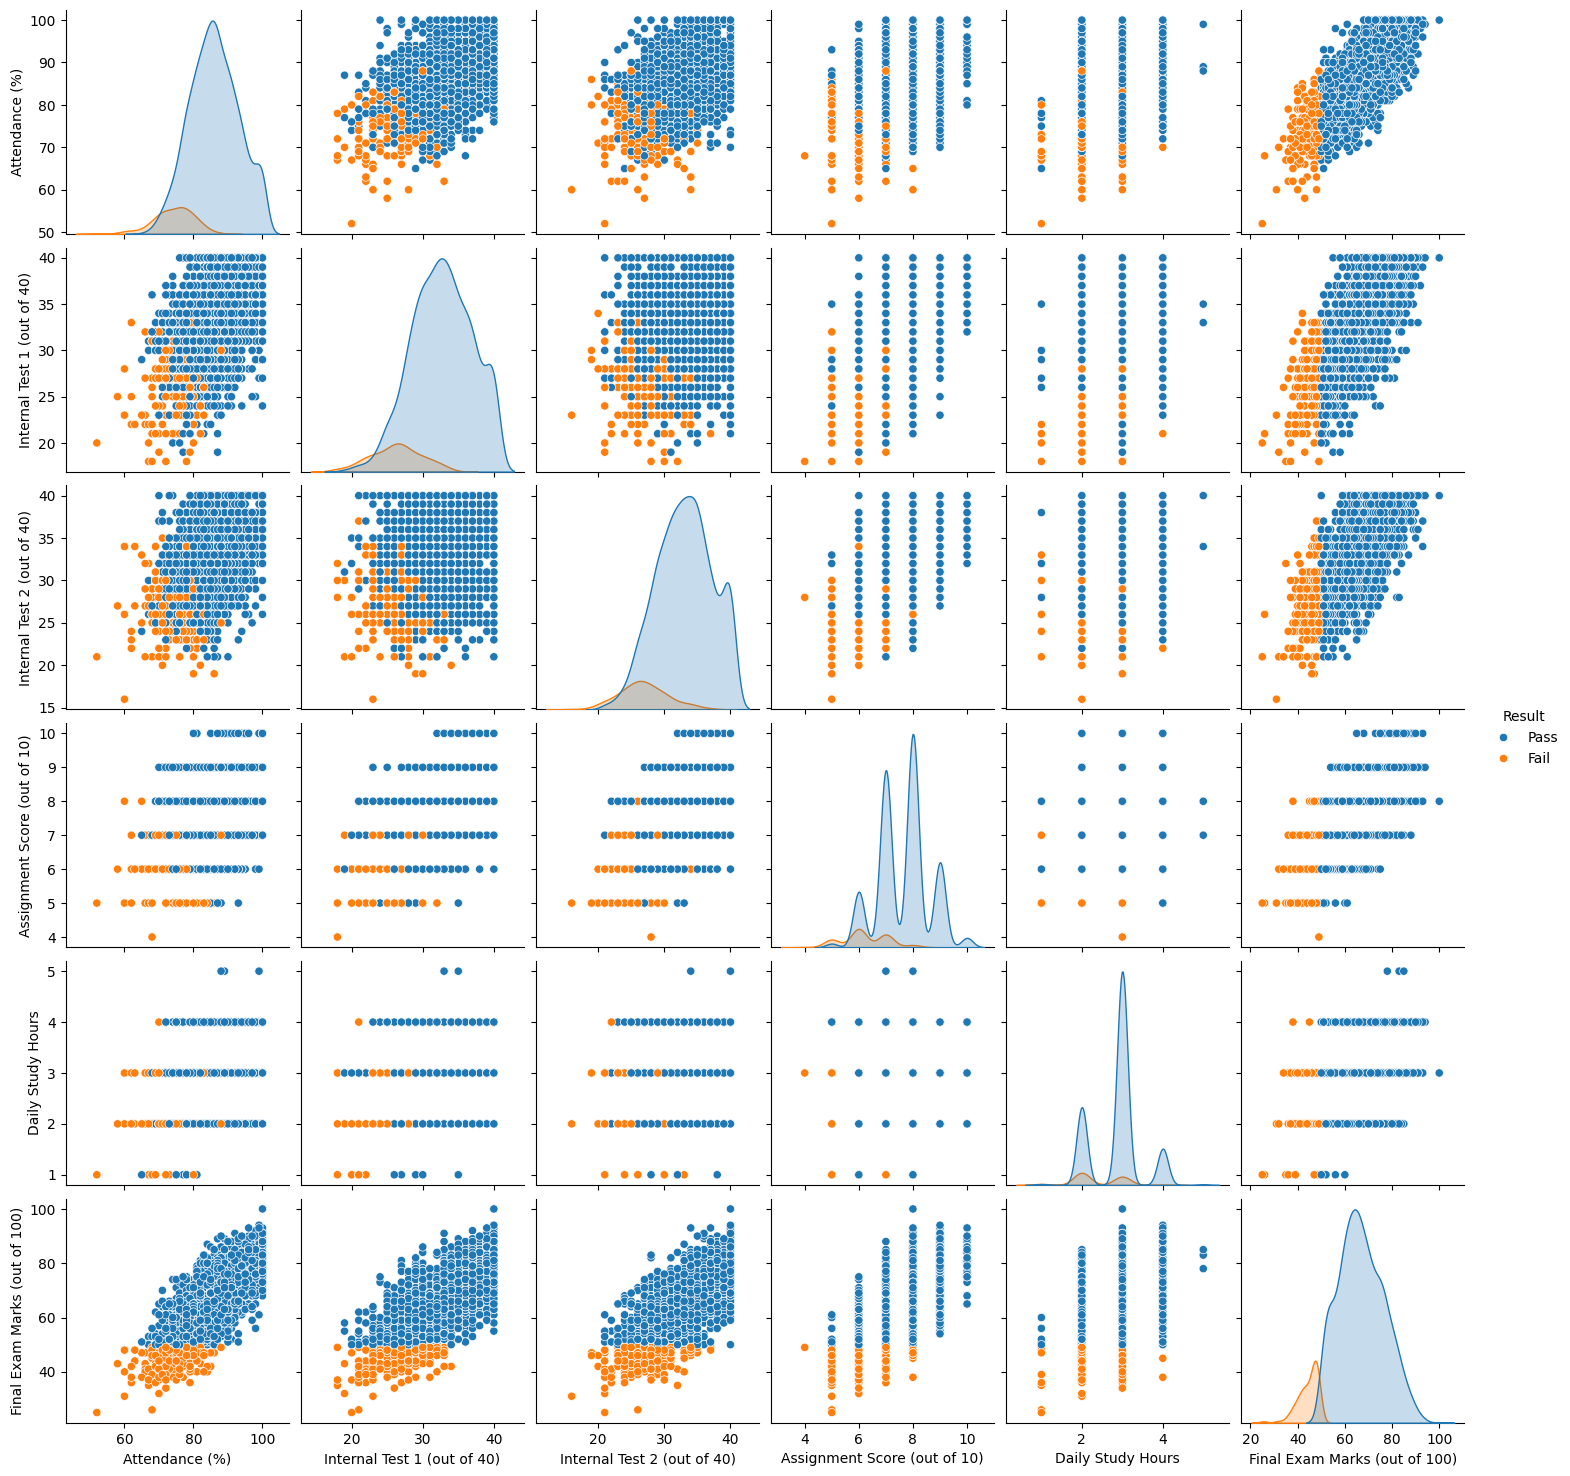

In [12]:
cols = [
    "Attendance (%)",
    "Internal Test 1 (out of 40)",
    "Internal Test 2 (out of 40)",
    "Assignment Score (out of 10)",
    "Daily Study Hours",
    "Final Exam Marks (out of 100)",
    "Result"
]

sns.pairplot(df[cols], hue="Result")
plt.show()

Feature Engineering

CA_Average

In [13]:
df['CA_Average'] = (
    df['Internal Test 1 (out of 40)'] +
    df['Internal Test 2 (out of 40)'] +
    (df['Assignment Score (out of 10)'] * 4)
) / 3

Study Efficiency Score

In [14]:
df['Study_Efficiency'] = (
    df['Attendance (%)'] *
    df['Daily Study Hours']
) / 10

Explanatory Data Analysis

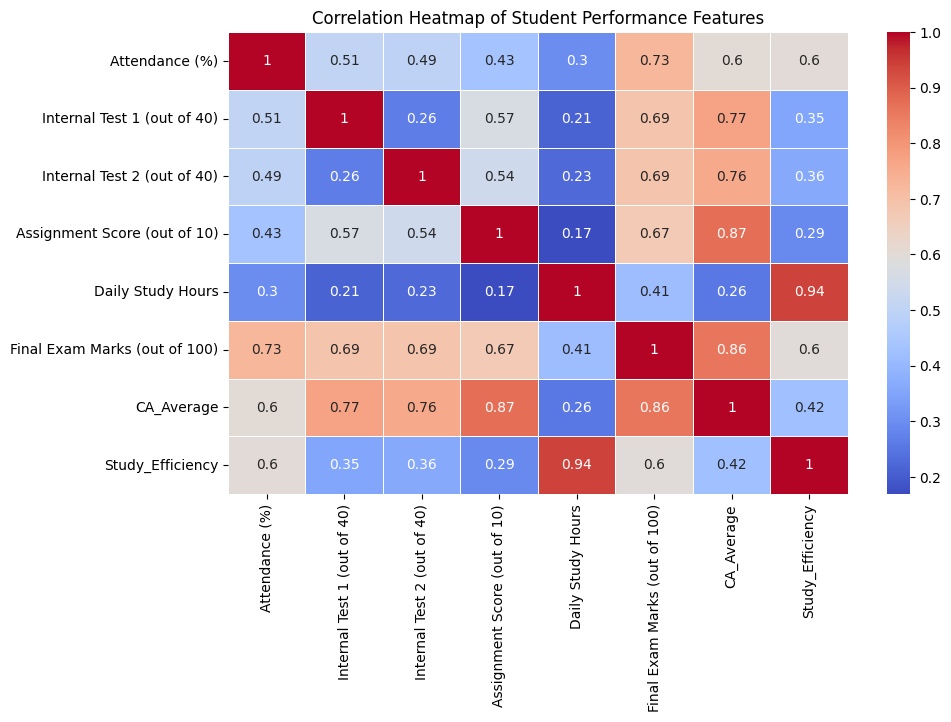

In [15]:
df_corr = df.select_dtypes(include=["int64", "float64"])

corr_matrix = df_corr.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Student Performance Features")
plt.show()

CA_Average vs Final Exam Marks

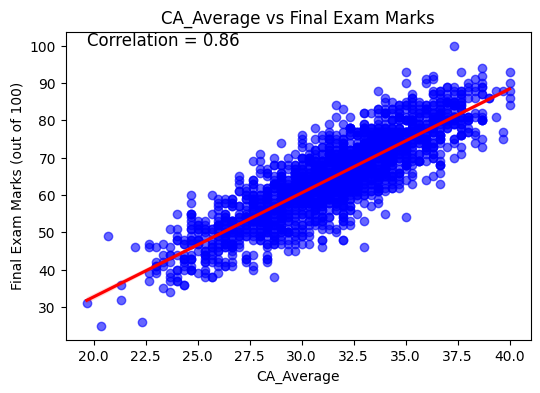

In [16]:
# Correlation value
corr, _ = pearsonr(df["CA_Average"], df["Final Exam Marks (out of 100)"])

plt.figure(figsize=(6,4))


sns.regplot(
    x="CA_Average",
    y="Final Exam Marks (out of 100)",
    data=df,
    scatter_kws={"alpha":0.6, "color":"blue"},
    line_kws={"color":"red"}
)

plt.text(
    x=df["CA_Average"].min(),
    y=df["Final Exam Marks (out of 100)"].max(),
    s=f"Correlation = {corr:.2f}",
    fontsize=12,
    color="black"
)

plt.title("CA_Average vs Final Exam Marks")
plt.show()

There is a strong positive correlation (0.86) between CA_Average and Final Exam Marks, indicating that students with higher continuous assessment performance tend to achieve better final exam results.

Study_Efficiency vs Final Exam Marks

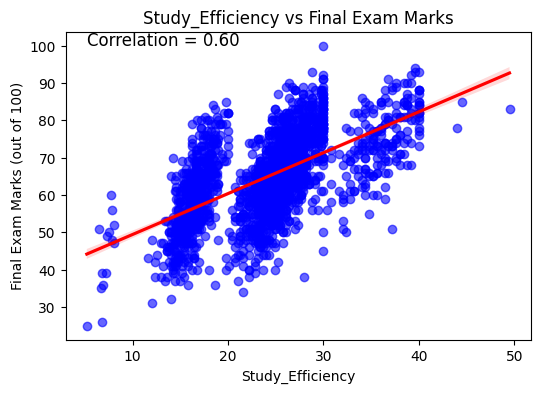

In [17]:
corr, _ = pearsonr(df["Study_Efficiency"], df["Final Exam Marks (out of 100)"])

plt.figure(figsize=(6,4))

sns.regplot(
    x="Study_Efficiency",
    y="Final Exam Marks (out of 100)",
    data=df,
    scatter_kws={"alpha":0.6, "color":"blue"},
    line_kws={"color":"red"}
)

plt.text(
    df["Study_Efficiency"].min(),
    df["Final Exam Marks (out of 100)"].max(),
    f"Correlation = {corr:.2f}",
    fontsize=12,
    color="black"
)

plt.title("Study_Efficiency vs Final Exam Marks")
plt.show()

The Study_Efficiency score, which combines Attendance (%) and Daily Study Hours, shows a moderate positive correlation (0.60) with Final Exam Marks. This indicates that students who consistently attend classes and spend more time studying tend to achieve better academic performance. However, the relationship is not very strong, suggesting that exam performance is also influenced by other factors such as understanding ability, exam preparation strategy, and difficulty level of assessments.

# Outlier Detection and Treatment

In [18]:
invalid_rows = df[
    (df['Attendance (%)'] < 0) | (df['Attendance (%)'] > 100) |
    (df['Internal Test 1 (out of 40)'] < 0) | (df['Internal Test 1 (out of 40)'] > 40) |
    (df['Internal Test 2 (out of 40)'] < 0) | (df['Internal Test 2 (out of 40)'] > 40) |
    (df['Assignment Score (out of 10)'] < 0) | (df['Assignment Score (out of 10)'] > 10) |
    (df['Final Exam Marks (out of 100)'] < 0) | (df['Final Exam Marks (out of 100)'] > 100) |
    (df['Daily Study Hours'] < 0) | (df['Daily Study Hours'] > 16)
]

print(invalid_rows)

Empty DataFrame
Columns: [Student_ID, Attendance (%), Internal Test 1 (out of 40), Internal Test 2 (out of 40), Assignment Score (out of 10), Daily Study Hours, Final Exam Marks (out of 100), Result, CA_Average, Study_Efficiency]
Index: []


Domain-based outlier detection was initially performed using logical minimum and maximum boundary validation. Academic-related attributes such as attendance, internal test marks, assignment scores, and final examination marks possess predefined valid ranges according to institutional grading standards.Additionally, daily study hours were constrained between 0 and 16 hours based on practical human daily activity limitations including sleep and personal activities.

The output gives empty DataFrame. It means thee are no any value that more than its range

Box Plot Visualization

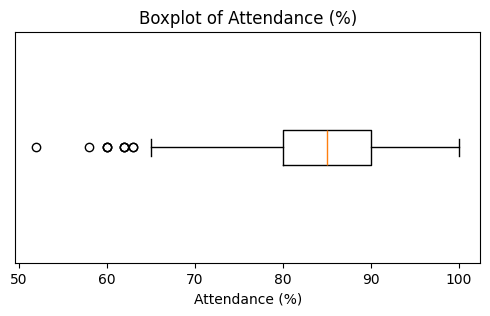

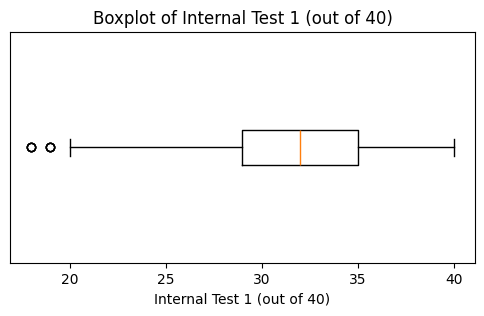

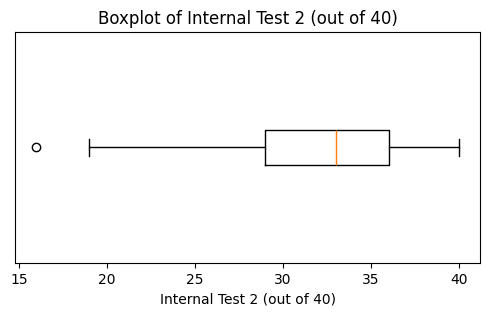

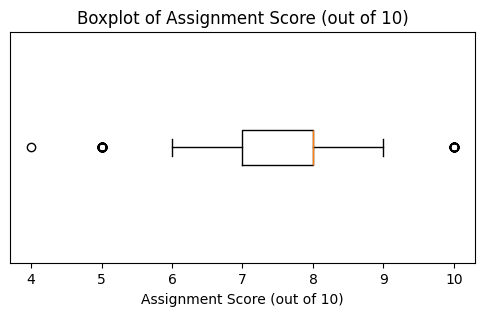

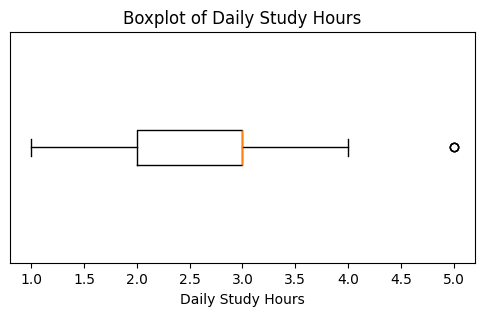

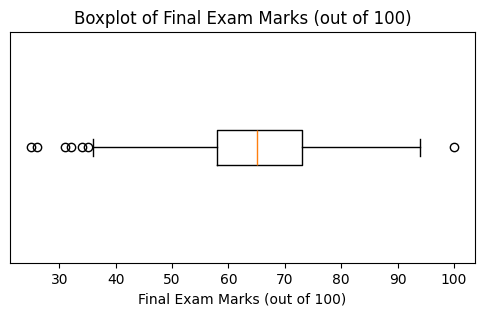

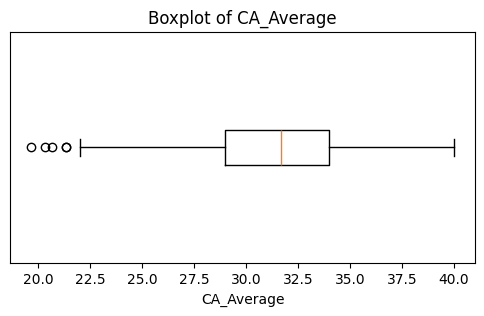

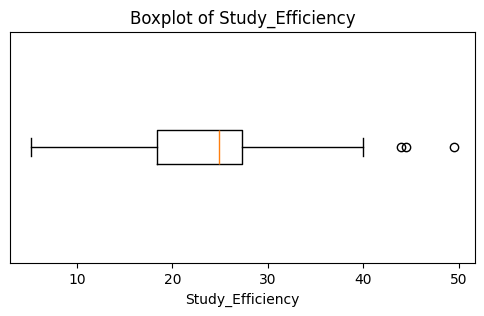

In [19]:
# numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Remove unwanted columns if they exist
#exclude_cols = ['Result']

#numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

# Create boxplots
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.yticks([])   # Removes index-like y-axis labels
    plt.show()

Detect Outliers Using IQR

In [20]:
numeric_cols = [
    'Attendance (%)',
    'Internal Test 1 (out of 40)',
    'Internal Test 2 (out of 40)',
    'Assignment Score (out of 10)',
    'Daily Study Hours',
    'Final Exam Marks (out of 100)'
]

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}")
    print(f"Number of outliers: {len(outliers)}")
    print("\n")

Attendance (%)
Number of outliers: 10


Internal Test 1 (out of 40)
Number of outliers: 8


Internal Test 2 (out of 40)
Number of outliers: 1


Assignment Score (out of 10)
Number of outliers: 79


Daily Study Hours
Number of outliers: 3


Final Exam Marks (out of 100)
Number of outliers: 7




In [21]:
display(outliers)


,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100),Result,CA_Average,Study_Efficiency
118,S1118,67,18,32,5,1,35,Fail,23.333333,6.7
678,S1678,60,23,16,5,2,31,Fail,19.666667,12.0
1007,S2007,100,40,40,8,3,100,Pass,37.333333,30.0
1194,S2194,68,21,26,5,1,26,Fail,22.333333,6.8
1205,S2205,70,19,21,6,2,32,Fail,21.333333,14.0
1564,S2564,52,20,21,5,1,25,Fail,20.333333,5.2
1614,S2614,72,26,21,6,3,34,Fail,23.666667,21.6


Although the IQR method detected some outliers, these values were considered normal and realistic for student performance data. Since they did not represent incorrect or impossible values, the outliers were not removed from the dataset.

# Feature Selection

In [69]:
X = df.drop(['Student_ID', 'Result','Final Exam Marks (out of 100)'], axis=1)

y = df['Result']

In [70]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

converts:

Pass → 1,
Fail → 0

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Feature Scaling

In [72]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1400, 7)
(600, 7)
(1400,)
(600,)


In the feature selection step, unnecessary columns such as Student_ID were removed because they do not contribute to predicting student results. The remaining attributes were used as input features, while the Result column was selected as the target variable. The target values were converted into numerical format using label encoding. After that, the dataset was divided into training and testing sets using an 70:30 ratio to evaluate model performance effectively.

# Class Balance Checking

In [74]:
print(pd.Series(y_train).value_counts())

1    1268
0     132
Name: count, dtype: int64


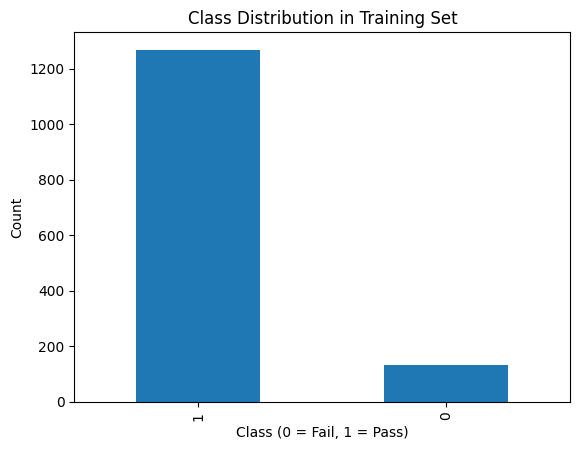

In [75]:
pd.Series(y_train).value_counts().plot(
    kind='bar'
)

plt.title("Class Distribution in Training Set")
plt.xlabel("Class (0 = Fail, 1 = Pass)")
plt.ylabel("Count")
plt.show()

Apply SMOTE on Training Data

In [76]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [77]:
print(pd.Series(y_train_resampled).value_counts())

1    1268
0    1268
Name: count, dtype: int64


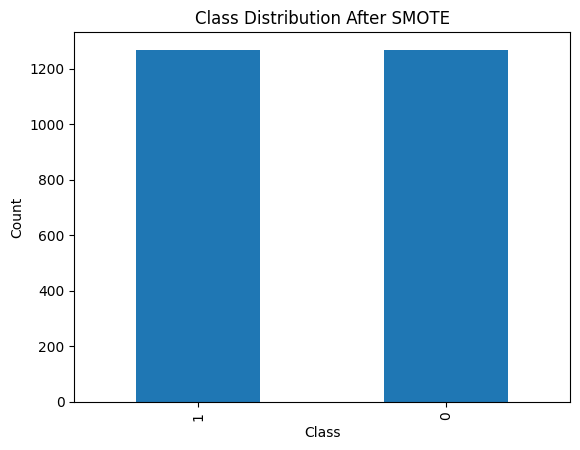

In [78]:
pd.Series(y_train_resampled).value_counts().plot(
    kind='bar'
)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

SMOTE was applied only on the training dataset to avoid data leakage. It generates synthetic samples for the minority class (Fail) by interpolating existing data points. This helps to balance the dataset and improves the model’s ability to learn both classes equally.

# Training Models

Logistic Regression

In [79]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_resampled, y_train_resampled)
y_pred_lr = lr.predict(X_test)

Decision Tree

In [80]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_resampled, y_train_resampled)
y_pred_dt = dt.predict(X_test)

Random Forest

In [60]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf.predict(X_test)

KNN

In [81]:
knn = KNeighborsClassifier()
knn.fit(X_train_resampled, y_train_resampled)
y_pred_knn = knn.predict(X_test)

XGBoost

In [82]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_resampled, y_train_resampled)
y_pred_xgb = xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:05:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Evaluate All Models

In [83]:
results = {
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr)
    ],
    "Decision Tree": [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt)
    ],
    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf)
    ],
    "KNN": [
        accuracy_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_knn)
    ],
    "XGBoost": [
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb)
    ]
}

In [84]:
results_df = pd.DataFrame(
    results,
    index=["Accuracy", "Precision", "Recall", "F1 Score"]
).T

print(results_df.sort_values(by="F1 Score", ascending=False))

                     Accuracy  Precision    Recall  F1 Score
Random Forest        0.940000   0.966912  0.966912  0.966912
Logistic Regression  0.931667   0.977230  0.946691  0.961718
Decision Tree        0.925000   0.964618  0.952206  0.958372
XGBoost              0.925000   0.969868  0.946691  0.958140
KNN                  0.901667   0.980198  0.909926  0.943756


Best model is Logistic Regression Model because it has Highest F1 score.

# Re-run models WITHOUT SMOTE

In [85]:
#Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

#KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

#XGBoost
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [86]:
results_no_smote = {
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr)
    ],
    "Decision Tree": [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt)
    ],
    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf)
    ],
    "KNN": [
        accuracy_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_knn)
    ],
    "XGBoost": [
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb)
    ]
}

results_df_no_smote = pd.DataFrame(
    results_no_smote,
    index=["Accuracy", "Precision", "Recall", "F1 Score"]
).T

print(results_df_no_smote.sort_values(by="F1 Score", ascending=False))

                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.948333   0.965517  0.977941  0.971689
KNN                  0.936667   0.960000  0.970588  0.965265
Random Forest        0.935000   0.961609  0.966912  0.964253
XGBoost              0.930000   0.959707  0.963235  0.961468
Decision Tree        0.920000   0.955882  0.955882  0.955882


Best model is Logistic Regression Model because it has Highest F1 score.

Finally Choose Non-SMOTE Logistic Regression model  because the non-SMOTE dataset produced slightly better and more realistic results. Logistic Regression achieved the highest F1-score on the original dataset and was selected as the final model due to its stable and consistent performance across all evaluation metrics.

# Final Model-Logisticc Regression

In [87]:
final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

Classification Report

In [88]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.66      0.70        56
           1       0.97      0.98      0.97       544

    accuracy                           0.95       600
   macro avg       0.86      0.82      0.84       600
weighted avg       0.95      0.95      0.95       600



Confusion Matrix

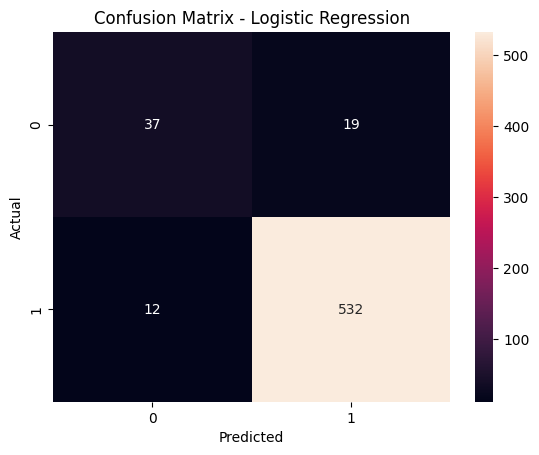

In [89]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [90]:
print(confusion_matrix(y_test, y_pred))

[[ 37  19]
 [ 12 532]]


True Negatives (37)

False Positives (19)

False Negatives (12)

True Positives (532)


The confusion matrix shows that the model performs well in predicting students who pass the course, with a high number of correct positive predictions. However, the model is less effective in identifying students who fail, as some misclassifications are present. Overall, the model shows strong performance but slightly favors the majority class.

Actual vs Predicted Visualization

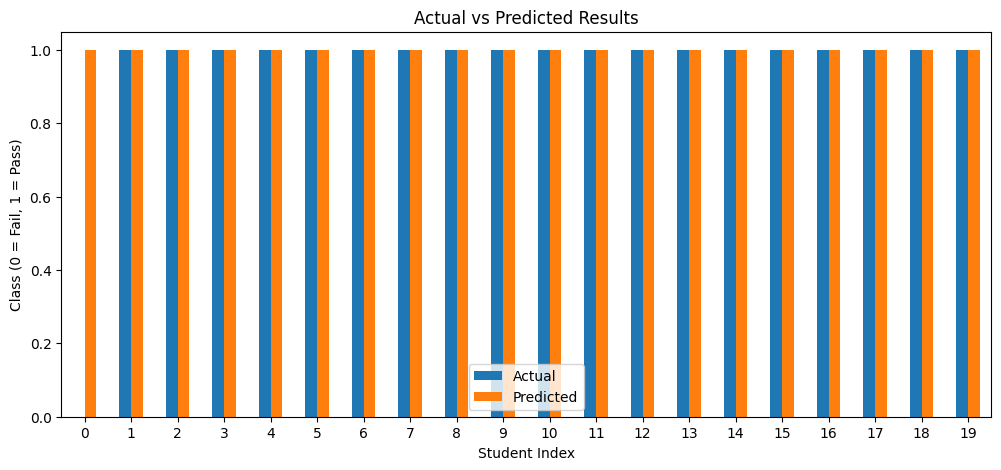

In [91]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

# Plot first 20 samples (recommended for clarity)
comparison.head(20).plot(kind='bar', figsize=(12,5))

plt.title('Actual vs Predicted Results')
plt.xlabel('Student Index')
plt.ylabel('Class (0 = Fail, 1 = Pass)')
plt.xticks(rotation=0)

plt.legend()
plt.show()

A comparison between actual and predicted values was visualized using a bar chart. This helps to understand how closely the model predictions match the real student outcomes. The results show that the model performs well in predicting student results.